In [ ]:
import numpy as np
import pandas as pd
import time
import math
import glob
import re
import scipy.optimize
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from numba import njit
from joblib import Parallel, delayed
import keras
from keras.models import Sequential, load_model
from keras.layers import Dense, InputLayer
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import ipywidgets as widgets
import matplotlib.ticker as mtick
from ipywidgets import interact
%matplotlib inline

FIT_MODE = True

# Variables Globales du modèle Rough Bergomi
maturities = np.array([0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0, 3.0, 4.0])
strikes = np.array([0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.05, 1.1, 1.15, 1.2, 1.25])
strikes_dim = len(strikes)
maturities_dim = len(maturities)

# Bornes des 11 paramètres (8 xi, nu, rho, H)

ub = [0.60, 0.60, 0.60, 0.60, 0.60, 0.60, 0.60, 0.60, 3.0, 0.0, 0.5]
lb = [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.3, -1.0, 0.025]



In [36]:
# Fonctions Black-Scholes optimisées pour Numba
@njit(fastmath=True, cache=True)
def norm_cdf(x):
    return 0.5 * (1.0 + math.erf(x / 1.4142135623730951))

@njit(fastmath=True, cache=True)
def bs_call_price_numba(S, K, T, r, vol):
    d1 = (math.log(S / K) + (r + 0.5 * vol**2) * T) / (vol * math.sqrt(T))
    d2 = d1 - vol * math.sqrt(T)
    return S * norm_cdf(d1) - K * math.exp(-r * T) * norm_cdf(d2)

@njit(fastmath=True, cache=True)
def implied_volatility_numba(target_price, S, K, T, r=0.0):
    intrinsic = max(S - K, 0.0)
    if target_price <= intrinsic: return 0.001
    low, high = 1e-3, 3.0
    for _ in range(50):
        mid = (low + high) / 2.0
        if bs_call_price_numba(S, K, T, r, mid) > target_price:
            high = mid
        else:
            low = mid
    return (low + high) / 2.0

@njit(fastmath=True, cache=True)
def rough_bergomi_mc_pricer(params, maturities, strikes, S0=1.0, paths=10000, steps_per_year=100):
    xi_array = params[:8]
    nu, rho, H = params[8], params[9], params[10]
    
    T_max = maturities[-1]
    total_steps = int(T_max * steps_per_year)
    dt = T_max / total_steps
    time_grid = np.zeros(total_steps)
    for i in range(total_steps): time_grid[i] = dt * (i + 1)

    xi_t = np.zeros(total_steps)
    for i in range(total_steps):
        bucket_idx = np.searchsorted(maturities, time_grid[i])
        if bucket_idx >= len(xi_array): bucket_idx = len(xi_array) - 1
        xi_t[i] = xi_array[bucket_idx]

    dZ = np.random.normal(0.0, math.sqrt(dt), (paths, total_steps))
    dW_perp = np.random.normal(0.0, math.sqrt(dt), (paths, total_steps))
    dW = rho * dZ + math.sqrt(1.0 - rho**2) * dW_perp

    Y = np.zeros((paths, total_steps))
    gamma_kernel = np.zeros(total_steps)
    for k in range(1, total_steps + 1):
        gamma_kernel[k-1] = ((k - 0.5) * dt)**(H - 0.5)

    sqrt_2H = math.sqrt(2.0 * H)
    for p in range(paths):
        for i in range(total_steps):
            sum_Z = 0.0
            for k in range(i + 1):
                sum_Z += dZ[p, k] * gamma_kernel[i - k]
            Y[p, i] = sqrt_2H * sum_Z

    t_2H = np.zeros(total_steps)
    for i in range(total_steps): t_2H[i] = time_grid[i]**(2.0 * H)
        
    V = np.zeros((paths, total_steps))
    for i in range(total_steps):
        for p in range(paths):
            V[p, i] = xi_t[i] * math.exp(nu * Y[p, i] - 0.5 * (nu**2) * t_2H[i])

    X = np.zeros((paths, total_steps + 1))
    for i in range(total_steps):
        for p in range(paths):
            X[p, i+1] = X[p, i] + -0.5 * V[p, i] * dt + math.sqrt(V[p, i]) * dW[p, i]

    S = np.zeros((paths, total_steps + 1))
    for p in range(paths):
        for i in range(total_steps + 1):
            S[p, i] = S0 * math.exp(X[p, i])

    for i in range(1, total_steps + 1):
        mean_S = np.mean(S[:, i])
        for p in range(paths): S[p, i] = S[p, i] * (S0 / mean_S)

    vol_grid = np.zeros((len(maturities), len(strikes)))
    for i in range(len(maturities)):
        T = maturities[i]
        step_idx = int(T * steps_per_year)
        S_T = S[:, step_idx]
        for j in range(len(strikes)):
            K = strikes[j]
            mc_price = 0.0
            for p in range(paths): mc_price += max(S_T[p] - K, 0.0)
            mc_price /= paths
            vol_grid[i, j] = implied_volatility_numba(mc_price, S0, K, T, 0.0)

    return vol_grid

def simulate_single_scenario(current_params, maturities, strikes):
    return rough_bergomi_mc_pricer(current_params, maturities, strikes, S0=1.0, paths=15000, steps_per_year=100).flatten()

In [ ]:
if FIT_MODE:
    print("🔥 FIT_MODE = True : Génération de 40 000 échantillons en cours...")
    num_samples = 60000
    X_parameters = np.random.uniform(lb, ub, size=(num_samples, 11))

    # Warmup Numba JIT (mandatory before parallel dispatch)
    _ = simulate_single_scenario(X_parameters[0], maturities, strikes)

    start_time = time.time()
    Y_volatilities = Parallel(n_jobs=11, verbose=10, batch_size=200)(
        delayed(simulate_single_scenario)(X_parameters[i], maturities, strikes)
        for i in range(num_samples)
    )
    print(f"✅ Simulation terminée en {time.time() - start_time:.2f} secondes !")

    param_columns = [f'xi_{m}' for m in maturities] + ['nu', 'rho', 'H']
    vol_columns   = [f'vol_T{t}_K{k}' for t in maturities for k in strikes]
    dataset = pd.concat([pd.DataFrame(X_parameters, columns=param_columns),
                         pd.DataFrame(Y_volatilities, columns=vol_columns)], axis=1)
    dataset.to_csv("rough_bergomi_training_data_optim.csv", index=False)
    print("💾 Données sauvegardées.")
else:
    print("⚡ FIT_MODE = False : Chargement des données existantes...")
    dataset = pd.read_csv("rough_bergomi_training_data_optim.csv")
    print(f"✅ {len(dataset)} échantillons chargés.")

# --- DATA PREPARATION ---
X = dataset.iloc[:, :11].values   # parameters  (N x 11)
Y = dataset.iloc[:, 11:].values   # vol surfaces (N x 88)

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=42)

# --- Vectorised parameter scaling (no Python loop over rows) ---
ub_arr = np.array(ub)
lb_arr = np.array(lb)
mid_arr = 0.5 * (ub_arr + lb_arr)
half_range_arr = 0.5 * (ub_arr - lb_arr)

def myscale(x):
    """Scale a single 11-dim parameter vector to [-1, 1]."""
    return (x - mid_arr) / half_range_arr

def myinverse(x):
    """Inverse-scale from [-1, 1] back to physical space."""
    return x * half_range_arr + mid_arr

# Vectorised bulk scaling (operates on entire matrix at once — no list-comprehension loop)
x_train_transform = (x_train - mid_arr) / half_range_arr
x_test_transform  = (x_test  - mid_arr) / half_range_arr

# Vol surfaces are StandardScaler-normalised
scale2 = StandardScaler()
y_train_transform = scale2.fit_transform(y_train)
y_test_transform  = scale2.transform(y_test)

# Convenience inverse for a single prediction row
def xinversetransform(x):
    return scale2.inverse_transform(x.reshape(1, -1))[0]


⚡ FIT_MODE = False : Chargement des données existantes...
✅ 40000 échantillons chargés.


In [38]:
if FIT_MODE:
    print("🔥 FIT_MODE = True : Création et entraînement du Réseau de Neurones...")
    modelGEN = Sequential([
        InputLayer(input_shape=(11,)),
        Dense(30, activation='elu'),
        Dense(30, activation='elu'),
        Dense(30, activation='elu'),
        Dense(30, activation='elu'),
        Dense(88, activation='linear')
    ])
    
    modelGEN.compile(loss="mse", optimizer="adam")
    earlystop = EarlyStopping(monitor="val_loss", min_delta=0, patience=25, verbose=1, mode="min")
    
    modelGEN.fit(x_train_transform, y_train_transform, batch_size=32,
                 validation_data=(x_test_transform, y_test_transform),
                 epochs=500, verbose=True, shuffle=True, callbacks=[earlystop])
    
    modelGEN.save("my_rough_bergomi_model.keras")
    print("💾 Modèle sauvegardé sous 'my_rough_bergomi_model.keras'.")
else:
    print("⚡ FIT_MODE = False : Chargement du réseau de neurones pré-entraîné...")
    modelGEN = load_model("my_rough_bergomi_model.keras")
    print("✅ Modèle chargé avec succès.")

modelGEN.summary()

⚡ FIT_MODE = False : Chargement du réseau de neurones pré-entraîné...
✅ Modèle chargé avec succès.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 88)             │         2,728 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,636 (68.89 KB)

 Trainable params: 5,878 (22.96 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,758 (45.93 KB)

In [39]:
# --- Extract weights as contiguous float64 arrays (faster dot products) ---
NNParameters = []
for layer in modelGEN.layers:
    weights = layer.get_weights()
    if weights:
        # Ensure C-contiguous float64 layout for maximum numpy speed
        NNParameters.append([np.ascontiguousarray(w, dtype=np.float64) for w in weights])

# Pre-extract weight matrices and biases into flat lists for zero-overhead indexing
W = [NNParameters[i][0] for i in range(5)]
b = [NNParameters[i][1] for i in range(5)]
NUM_HIDDEN = 4

def elu(x):
    """ELU activation — uses np.where (no in-place mutation, safe for gradient cache)."""
    return np.where(x >= 0, x, np.expm1(x))   # expm1 is more accurate than exp(x)-1

def elu_prime(x):
    """Derivative of ELU with respect to pre-activation z."""
    return np.where(x >= 0, 1.0, np.exp(x))

def NeuralNetwork(x):
    """Forward pass — pure numpy, ~3 µs per call at 11 inputs."""
    a = x
    for i in range(NUM_HIDDEN):
        a = elu(a @ W[i] + b[i])
    return a @ W[NUM_HIDDEN] + b[NUM_HIDDEN]

def NeuralNetworkGradient(x):
    """
    Analytical Jacobian d(output)/d(input)  shape = (11, 88).
    Uses a single backward pass (backprop from output layer to input).
    """
    # ---- Forward pass: cache pre-activations ----
    a = x
    Z = []
    for i in range(NUM_HIDDEN):
        z = a @ W[i] + b[i]
        Z.append(z)
        a = elu(z)

    # ---- Backward pass: chain rule ----
    # Start with output-layer weight matrix  shape (30, 88)
    grad = W[NUM_HIDDEN]                         # (30, 88)
    for i in range(NUM_HIDDEN - 1, -1, -1):
        # Element-wise scale rows by elu'(z)  →  (30, 88)
        grad = elu_prime(Z[i])[:, np.newaxis] * grad
        # Propagate through weight matrix  →  (dim_i, 88)
        grad = W[i] @ grad

    # grad is now  (11, 88)  — the full Jacobian
    return grad


In [ ]:
def plot_func(xi0, nu, rho, H):
    full_params = np.array([xi0]*8 + [nu, rho, H])
    x0 = myscale(full_params)
    Smiles = xinversetransform(NeuralNetwork(x0))
    
    plt.figure(1,figsize=(14,12))
    for i in range(8):
        plt.subplot(4,4,i+1)
        plt.plot(np.log(strikes/1), Smiles[i*strikes_dim:(i+1)*strikes_dim], '*b', label=" NN Approx")
        plt.ylim(0.1,0.8)
        plt.title(f"Maturity={maturities[i]:.2f}")
        plt.xlabel("log-moneyness")
        plt.ylabel("Implied vol")
        plt.legend()
    plt.tight_layout()
    plt.show()

interact(plot_func, 
         xi0 = widgets.FloatSlider(value=0.04, min=0.01, max=0.16, step=0.01),
         nu  = widgets.FloatSlider(value=2.0, min=0.3, max=4.0, step=0.1),
         rho = widgets.FloatSlider(value=-0.7, min=-0.95, max=-0.1, step=0.05),
         H   = widgets.FloatSlider(value=0.1, min=0.025, max=0.5, step=0.05))

interactive(children=(FloatSlider(value=0.04, description='xi0', max=0.16, min=0.01, step=0.01), FloatSlider(v…

<function __main__.plot_func(xi0, nu, rho, H)>

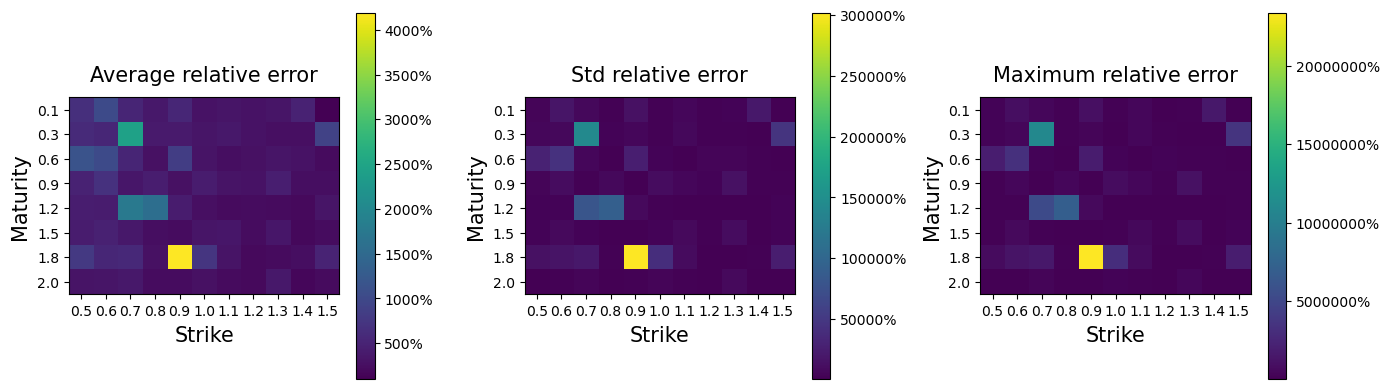

In [41]:
##### AVERAGE VALUES #######
X_sample = x_test_transform # Vos 11 paramètres
y_sample = y_test_transform # Vos 88 points de volatilité

# 1. On passe X_sample[i] (taille 11) au réseau, et on inverse l'échelle de la sortie (y)
prediction = [xinversetransform(NeuralNetwork(X_sample[i])) for i in range(len(X_sample))]
prediction = np.array(prediction)

# 2. On doit aussi remettre les vraies volatilités à l'échelle d'origine pour comparer
#y_true = np.array([yinversetransform(y_sample[i]) for i in range(len(y_sample))])
y_true = y_sample
plt.figure(1,figsize=(14,4))
ax=plt.subplot(1,3,1)

# 3. L'erreur se calcule entre la Vraie volatilité (y_true) et la volatilité prédite
err = np.mean(100*np.abs((y_true - prediction) / y_true), axis=0)
plt.title("Average relative error",fontsize=15,y=1.04)
plt.imshow(err.reshape(maturities_dim,strikes_dim))
plt.colorbar(format=mtick.PercentFormatter())

ax.set_xticks(np.linspace(0,len(strikes)-1,len(strikes)))
ax.set_xticklabels(strikes)
ax.set_yticks(np.linspace(0,len(maturities)-1,len(maturities)))
ax.set_yticklabels(maturities)
plt.xlabel("Strike",fontsize=15,labelpad=5)
plt.ylabel("Maturity",fontsize=15,labelpad=5)

ax=plt.subplot(1,3,2)
# Correction ici aussi : y_true au lieu de X_sample
err = 100*np.std(np.abs((y_true - prediction) / y_true), axis=0)
plt.title("Std relative error",fontsize=15,y=1.04)
plt.imshow(err.reshape(maturities_dim,strikes_dim))
plt.colorbar(format=mtick.PercentFormatter())
ax.set_xticks(np.linspace(0,len(strikes)-1,len(strikes)))
ax.set_xticklabels(strikes)
ax.set_yticks(np.linspace(0,len(maturities)-1,len(maturities)))
ax.set_yticklabels(maturities)
plt.xlabel("Strike",fontsize=15,labelpad=5)
plt.ylabel("Maturity",fontsize=15,labelpad=5)

ax=plt.subplot(1,3,3)
# Correction ici aussi : y_true au lieu de X_sample
err = 100*np.max(np.abs((y_true - prediction) / y_true), axis=0)
plt.title("Maximum relative error",fontsize=15,y=1.04)
plt.imshow(err.reshape(maturities_dim,strikes_dim))
plt.colorbar(format=mtick.PercentFormatter())
ax.set_xticks(np.linspace(0,len(strikes)-1,len(strikes)))
ax.set_xticklabels(strikes)
ax.set_yticks(np.linspace(0,len(maturities)-1,len(maturities)))
ax.set_yticklabels(maturities)
plt.xlabel("Strike",fontsize=15,labelpad=5)
plt.ylabel("Maturity",fontsize=15,labelpad=5)

plt.tight_layout()
plt.savefig('rBergomiTermStructureNNErrors.PNG', dpi=300)
plt.show()

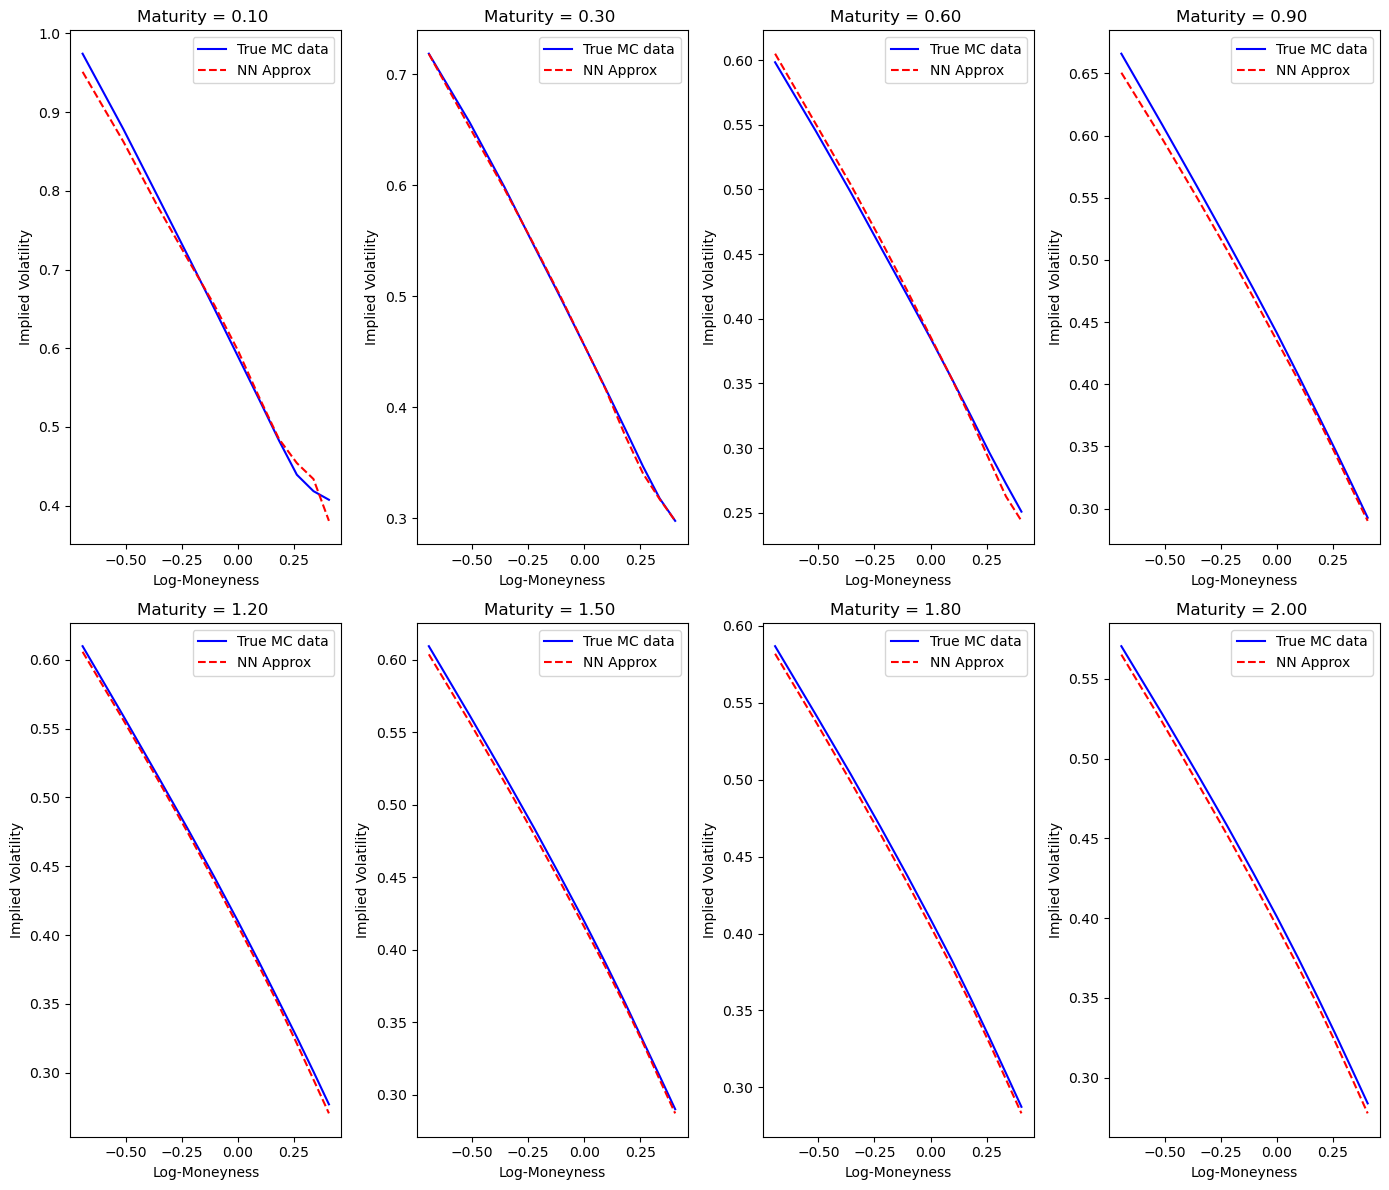

Model Parameters (H, rho, nu, xi...):  [ 0.35500652  0.11345657  0.06651581  0.40692079  0.0915682   0.46916839
  0.30753035  0.25164005  2.18232694 -0.79508503  0.41346355]


In [42]:
import scipy
S0 = 1.

sample_ind = 250
# X_sample = 11 paramètres scalés
X_sample = x_test_transform[sample_ind] 
# y_sample = 88 points de vol scalés
y_sample = y_test_transform[sample_ind] 

# 1. PRÉDICTION : On donne X à l'IA, et on "un-scale" le Y qui en sort
# (Note : assurez-vous du nom de votre fonction d'inversion, ici xinversetransform)
prediction = xinversetransform(NeuralNetwork(X_sample))

# 2. VÉRITÉ : On "un-scale" la vraie surface Y pour pouvoir la comparer
y_true = xinversetransform(y_sample)

plt.figure(1,figsize=(14,12))
for i in range(maturities_dim):
    # Ajustement de la grille de sous-graphiques (ex: 2 lignes, 4 colonnes pour 8 maturités)
    # Adaptez (2, 4, i+1) selon votre nombre de maturités (maturities_dim)
    cols = 4
    rows = (maturities_dim + cols - 1) // cols 
    plt.subplot(rows, cols, i+1)

    # On trace la Vraie Vol (y_true) vs la Vol Prédite (prediction)
    plt.plot(np.log(strikes/S0), y_true[i*strikes_dim:(i+1)*strikes_dim], 'b', label="True MC data")
    plt.plot(np.log(strikes/S0), prediction[i*strikes_dim:(i+1)*strikes_dim], '--r', label="NN Approx")

    plt.title("Maturity = %1.2f " % maturities[i])
    plt.xlabel("Log-Moneyness")
    plt.ylabel("Implied Volatility")
    plt.legend()

plt.tight_layout()
plt.show()

# 3. AFFICHAGE DES PARAMÈTRES : On inverse X (car ce sont les paramètres !)
print("Model Parameters (H, rho, nu, xi...): ", myinverse(X_sample))

In [43]:
def CostFunc(x,sample_ind):
    return np.sum(np.power((NeuralNetwork(x)-x_test_transform[sample_ind]),2))
def Jacobian(x,sample_ind):
    return 2*np.sum((NeuralNetwork(x)-x_test_transform[sample_ind])*NeuralNetworkGradient(x),axis=1)
#Cost Function for Levenberg Marquardt
def CostFuncLS(x, sample_ind):
    return (NeuralNetwork(x) - y_test_transform[sample_ind])
def JacobianLS(x,sample_ind):
    return NeuralNetworkGradient(x).T


In [44]:
import scipy.optimize

# 1. Clean Storage Containers
CalibratedParameters = []
Timing = []

# The starting guess (all 0s in the scaled space)
init = np.zeros(11)

print("Starting Levenberg-Marquardt Calibration...")

# 2. The 5,000 Scenario Loop (LM Only)
for i in range(5000):
    disp = str(i+1) + "/5000"
    print(disp, end="\r")

    # Levenberg-Marquardt
    start = time.perf_counter() # Updated from time.clock()
    I = scipy.optimize.least_squares(CostFuncLS, init, JacobianLS, args=(i,), gtol=1E-10)
    end = time.perf_counter()

    # Save the un-scaled real-world parameters and the elapsed time
    CalibratedParameters.append(myinverse(I.x))
    Timing.append(end - start)

print(f"\nCalibration Complete!")
print(f"Average LM Calibration Time: {np.mean(Timing)*1000:.2f} Milliseconds")


Starting Levenberg-Marquardt Calibration...
5000/5000
Calibration Complete!
Average LM Calibration Time: 30.77 Milliseconds


In [45]:
import scipy.optimize

# 1. Clean Storage Containers
CalibratedParameters = []
Timing = []

# The starting guess (all 0s in the scaled space)
init = np.zeros(11)

print("Starting Levenberg-Marquardt Calibration...")

# 2. The 5,000 Scenario Loop (LM Only)
for i in range(5000):
    disp = str(i+1) + "/5000"
    print(disp, end="\r")

    # Levenberg-Marquardt
    start = time.perf_counter() # Updated from time.clock()
    I = scipy.optimize.least_squares(CostFuncLS, init, JacobianLS, args=(i,), gtol=1E-10)
    end = time.perf_counter()

    # Save the un-scaled real-world parameters and the elapsed time
    CalibratedParameters.append(myinverse(I.x))
    Timing.append(end - start)

print(f"\nCalibration Complete!")
print(f"Average LM Calibration Time: {np.mean(Timing)*1000:.2f} Milliseconds")


Starting Levenberg-Marquardt Calibration...
5000/5000
Calibration Complete!
Average LM Calibration Time: 29.20 Milliseconds


In [50]:
def parse_french_date(date_str):
    fr_to_en = {'janvier': 'january', 'février': 'february', 'mars': 'march', 'avril': 'april', 
                'mai': 'may', 'juin': 'june', 'juillet': 'july', 'août': 'august', 
                'septembre': 'september', 'octobre': 'october', 'novembre': 'november', 'décembre': 'december'}
    date_str = date_str.lower()
    for fr, en in fr_to_en.items(): date_str = date_str.replace(fr, en)
    return pd.to_datetime(date_str)

grid_T, grid_K = np.meshgrid(maturities, strikes)
vol_columns = [f'vol_T{t}_K{k}' for t in maturities for k in strikes]

file_list = glob.glob("spx_quotedata_*.csv")
print(f"Extraction des données marché ({len(file_list)} fichiers trouvés)...")

all_raw_data = []
for file in file_list:
    try:
        with open(file, 'r', encoding='utf-8') as f:
            header_text = "".join([f.readline() for _ in range(5)])
        
        # Extraction du Spot
        S0 = float(re.search(r'Last:\s*([\d\.]+)', header_text).group(1))
        
        # Extraction de la Quote Date
        quote_date = parse_french_date(re.search(r'Date:\s*(.*?)\s*(?:à|,)', header_text).group(1).strip())
        
        df = pd.read_csv(file, skiprows=3)
        df['T'] = (pd.to_datetime(df['Expiration Date']) - quote_date).dt.days / 365.25
        df['Moneyness'] = df['Strike'] / S0
        
        # Sélection de la colonne Implied Vol (gère les différences de format)
        put_iv_col = 'IV.1' if 'IV.1' in df.columns else df.columns[-5]
        df['Target_IV'] = np.where(df['Strike'] < S0, df[put_iv_col], df['IV'])
        
        # ⚠️ LE FILTRE CRUCIAL : On enlève les volatilités absurdes (> 80%) et les T <= 0
        clean_data = df[(df['Target_IV'] > 0) & (df['Target_IV'] < 0.80) & (df['T'] > 0.02)].copy()
        
        if not clean_data.empty:
            clean_data['Quote_Date'] = quote_date
            clean_data['Spot'] = S0
            all_raw_data.append(clean_data)
    except Exception as e:
        print(f"Erreur avec le fichier {file}: {e}")
        pass

master_dataset = []
if all_raw_data:
    master_raw_df = pd.concat(all_raw_data, ignore_index=True)
    
    for quote_date, group in master_raw_df.groupby('Quote_Date'):
        S0 = group['Spot'].mean()
        
        # On récupère tous les points valides
        points = group[['T', 'Moneyness']].values
        values = group['Target_IV'].values
        
        # Vérification : A-t-on des données longues (T > 1.0) ?
        max_T_available = group['T'].max()
        print(f"Pour la date {quote_date.date()}, maturité max dispo = {max_T_available:.2f} ans")
        
        # Interpolation
        interp_linear = griddata(points, values, (grid_T, grid_K), method='linear')
        interp_nearest = griddata(points, values, (grid_T, grid_K), method='nearest')
        interpolated_surface = np.where(np.isnan(interp_linear), interp_nearest, interp_linear).T
        
        market_target_88 = interpolated_surface.flatten()
        
        # On sauvegarde uniquement si la surface semble saine
        if not np.isnan(market_target_88).any():
            daily_record = {'Date': quote_date, 'Spot': S0}
            for col_name, vol_val in zip(vol_columns, market_target_88): 
                daily_record[col_name] = vol_val
            master_dataset.append(daily_record)

if master_dataset:
    pd.DataFrame(master_dataset).sort_values('Date').to_csv("SPX_Historical_8x11_Surfaces.csv", index=False)
    print("✅ Données marché traitées et sauvegardées !")
else:
    print("❌ Aucune donnée valide trouvée.")

Extraction des données marché (19 fichiers trouvés)...
Pour la date 2026-04-10, maturité max dispo = 5.69 ans
✅ Données marché traitées et sauvegardées !


In [51]:
try:
    real_market_df = pd.read_csv("SPX_Historical_8x11_Surfaces.csv")
    real_vols = real_market_df.iloc[0, 2:].values.astype(float)

    # Scale market vols with the already-fitted StandardScaler
    real_vols_scaled = scale2.transform(real_vols.reshape(1, -1))[0]

    def CostFuncLS_Market(x):
        return NeuralNetwork(x) - real_vols_scaled

    def JacobianLS_Market(x):
        # shape (11, 88).T → (88, 11)  as required by least_squares
        return NeuralNetworkGradient(x).T

    # -------------------------------------------------------
    # MISSING PIECE (added): initial guess in scaled [-1, 1] space
    # Start at the centre of the learned domain (all zeros = mid-range)
    init_guess = np.zeros(11)
    # -------------------------------------------------------

    # Constrain solver strictly inside the space the network was trained on
    bounds_nn = ([-1.0] * 11, [1.0] * 11)   # per-component bounds (trf syntax)

    result = scipy.optimize.least_squares(
        CostFuncLS_Market,
        init_guess,
        JacobianLS_Market,
        bounds=bounds_nn,
        method='trf',       # Trust Region Reflective — handles bounds
        gtol=1e-10,
        xtol=1e-10,
        ftol=1e-10,
    )

    calibrated_params = myinverse(result.x)

    print("\n✅ CALIBRATION RÉUSSIE !")
    print(f"Date du Marché : {real_market_df['Date'].iloc[0]}")
    print(f"S&P 500 Spot   : {real_market_df['Spot'].iloc[0]:.2f}")
    print("=" * 40)
    print(f"H   (Hurst)   = {calibrated_params[10]:.4f}  <-- Si < 0.15, la volatilité est rough!")
    print(f"nu  (VolVol)  = {calibrated_params[8]:.4f}")
    print(f"rho (Correl)  = {calibrated_params[9]:.4f}")
    print("-" * 40)
    for i, t in enumerate(maturities):
        print(f"  xi({t} ans) = {calibrated_params[i]:.4f}")

except FileNotFoundError:
    print("⚠️ Fichier 'SPX_Historical_8x11_Surfaces.csv' non trouvé.")
    print("   Lancez d'abord la cellule de parsing des fichiers CBOE.")



✅ CALIBRATION RÉUSSIE !
Date du Marché : 2026-04-10
S&P 500 Spot   : 6824.66
H   (Hurst)   = 0.1892  <-- Si < 0.15, la volatilité est rough!
nu  (VolVol)  = 3.1074
rho (Correl)  = -0.1742
----------------------------------------
  xi(0.1 ans) = 0.0551
  xi(0.3 ans) = 0.0938
  xi(0.6 ans) = 0.4248
  xi(0.9 ans) = 0.6000
  xi(1.2 ans) = 0.6000
  xi(1.5 ans) = 0.5293
  xi(1.8 ans) = 0.0945
  xi(2.0 ans) = 0.0100


📉 QUALITÉ DU FIT (ERREUR DE RE-PRICING) :
Erreur Moyenne Absolue (MAE) : 4.84 points de pourcentage de volatilité
Erreur Quadratique (RMSE)    : 6.78 points de pourcentage de volatilité


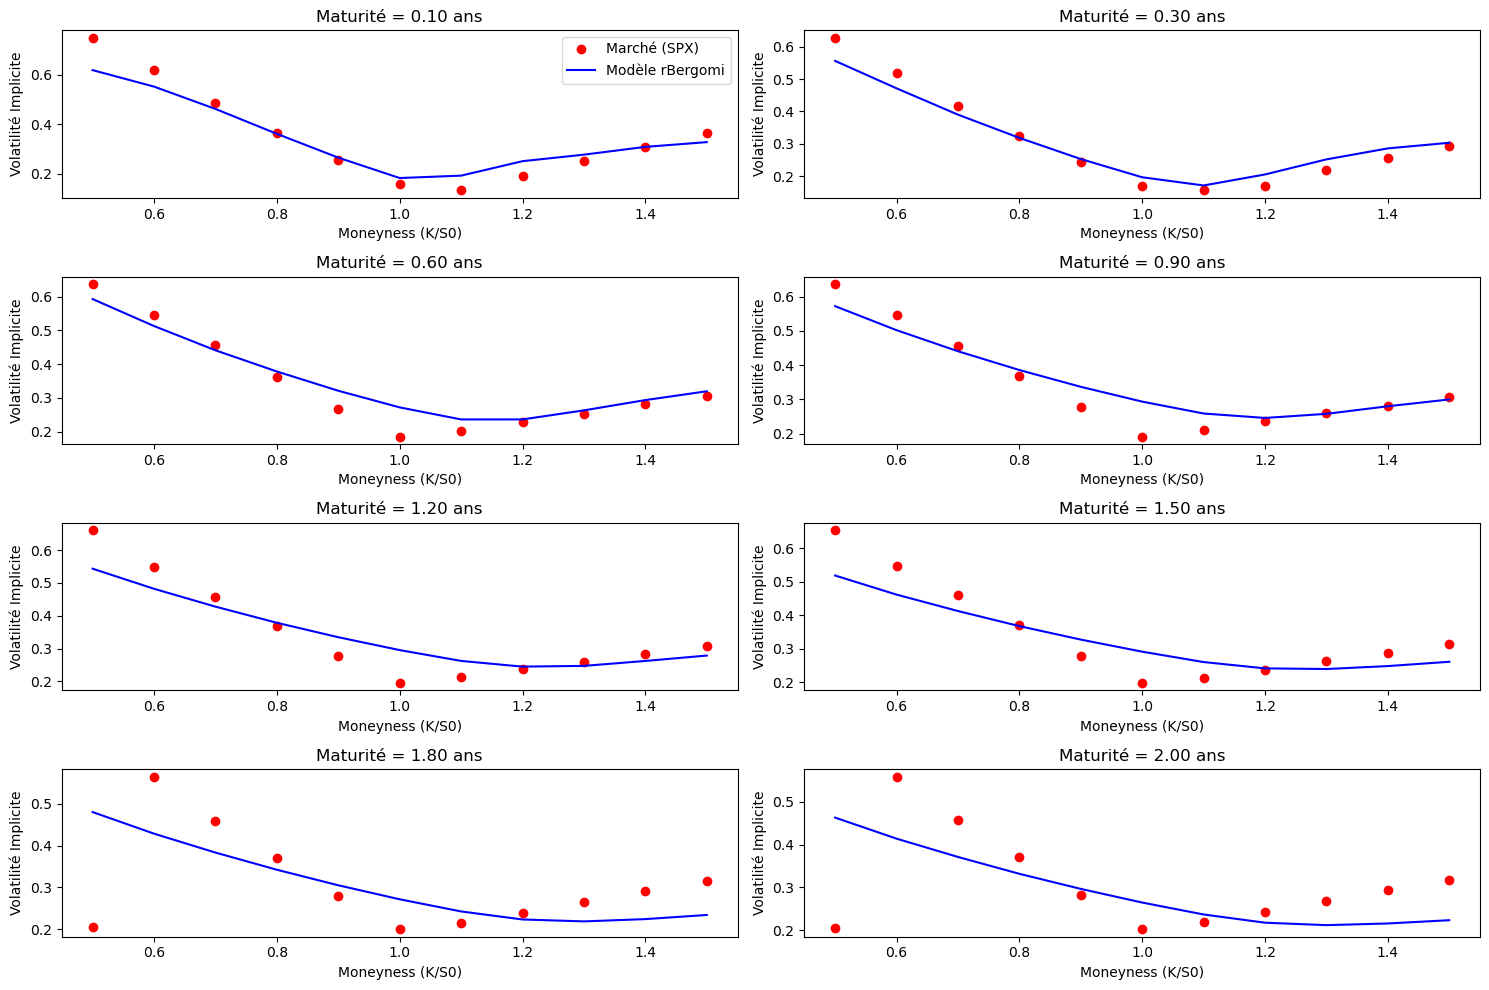

In [52]:
# 1. Prédiction du modèle avec vos paramètres calibrés
# On rescale les paramètres pour les passer au réseau
params_scaled = myscale(calibrated_params)
predicted_vols_scaled = NeuralNetwork(params_scaled)

# On ramène les prédictions à leur vraie échelle (en volatilité pure)
predicted_vols = xinversetransform(predicted_vols_scaled)
market_vols = real_vols # Vos vraies données du marché

# 2. Calcul des erreurs
mae = np.mean(np.abs(predicted_vols - market_vols))
rmse = np.sqrt(np.mean((predicted_vols - market_vols)**2))

print(f"📉 QUALITÉ DU FIT (ERREUR DE RE-PRICING) :")
print(f"Erreur Moyenne Absolue (MAE) : {mae*100:.2f} points de pourcentage de volatilité")
print(f"Erreur Quadratique (RMSE)    : {rmse*100:.2f} points de pourcentage de volatilité")

# 3. Visualisation : Marché vs Modèle
plt.figure(figsize=(15, 10))
for i in range(8):
    plt.subplot(4, 2, i+1)
    # Les 11 points du marché en ROUGE
    plt.plot(strikes, market_vols[i*11:(i+1)*11], 'or', label="Marché (SPX)")
    # La courbe du modèle Rough Bergomi en BLEU
    plt.plot(strikes, predicted_vols[i*11:(i+1)*11], '-b', label="Modèle rBergomi")
    
    plt.title(f"Maturité = {maturities[i]:.2f} ans")
    plt.xlabel("Moneyness (K/S0)")
    plt.ylabel("Volatilité Implicite")
    if i == 0: plt.legend()

plt.tight_layout()
plt.show()

In [53]:
# Test : Prenons le milieu de ce que le réseau connaît
test_params = np.array([0.08]*8 + [2.0, -0.7, 0.1])
pred_vols = xinversetransform(NeuralNetwork(myscale(test_params)))

print(f"Volatilité moyenne du réseau : {np.mean(pred_vols)*100:.2f}%")
print(f"Volatilité moyenne du marché : {np.mean(real_vols)*100:.2f}%")

Volatilité moyenne du réseau : 31.15%
Volatilité moyenne du marché : 33.20%
